 # **This Technique apply only on  Skewed Distributed Data**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv('placement.csv')

In [59]:
# Total Data
df.shape

(1000, 3)

In [60]:
df.sample(5)

,cgpa,placement_exam_marks,placed
523,6.13,19.0,0
474,7.11,25.0,1
528,6.90,38.0,1
541,6.11,18.0,1
147,6.68,11.0,0


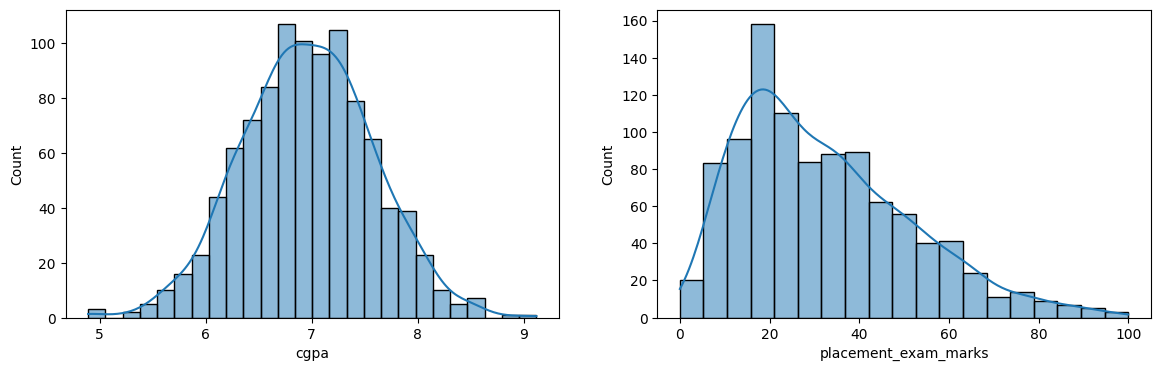

In [61]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['cgpa'] , kde=True)

plt.subplot(122)
sns.histplot(df['placement_exam_marks'] , kde=True)
plt.show()

In [62]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [63]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

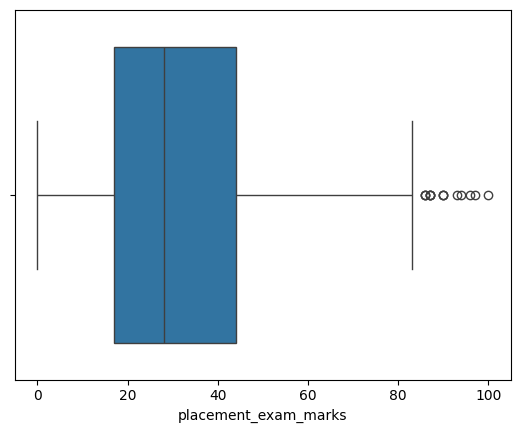

In [64]:
sns.boxplot(x = df['placement_exam_marks'])
plt.show()

In [65]:
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)


In [66]:
IQR = Q3-Q1 

# **Trimming With limit**

In [67]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

In [68]:
print("Upper_limit" , upper_limit)
print("lower_limit" , lower_limit)

Upper_limit 84.5
lower_limit -23.5


# **Finding Outliers**

In [69]:
df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [70]:
Trim_df = df [(df['placement_exam_marks'] < upper_limit) & (df['placement_exam_marks'] > lower_limit)]

In [71]:
Trim_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


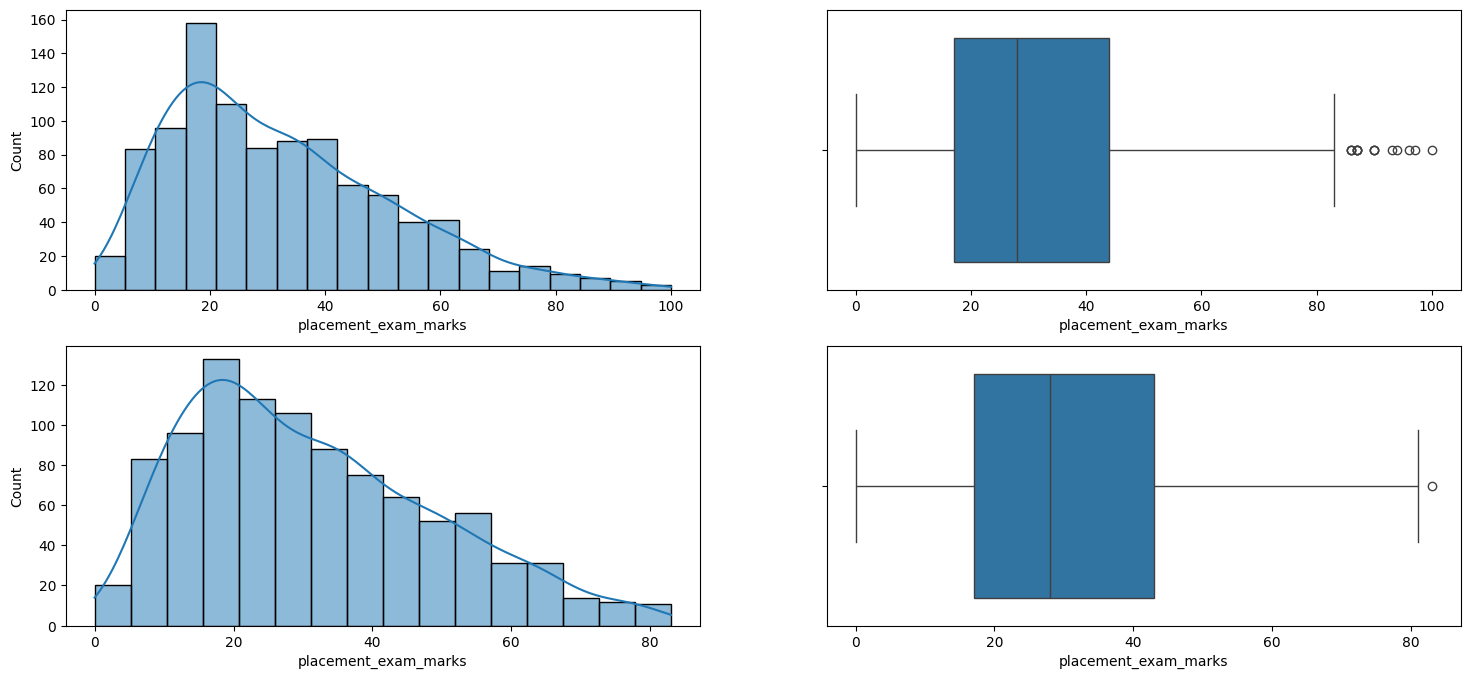

In [77]:
# Comparing Before After Removing Outlier

plt.figure(figsize=(18,8))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'] , kde=True)

plt.subplot(222)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(223)
sns.histplot(Trim_df['placement_exam_marks'] , kde=True)

plt.subplot(224)
sns.boxplot(x = Trim_df['placement_exam_marks'])

plt.show()


# **Capping Outlier With Limits**

In [74]:
new_df = df.copy()

new_df['placement_exam_marks'] = np.where(
    new_df['placement_exam_marks'] > upper_limit,
    upper_limit ,
    np.where(
        new_df['placement_exam_marks']  < lower_limit ,
        lower_limit,
        new_df['placement_exam_marks']    
    )
)


In [76]:
new_df.shape


(1000, 3)

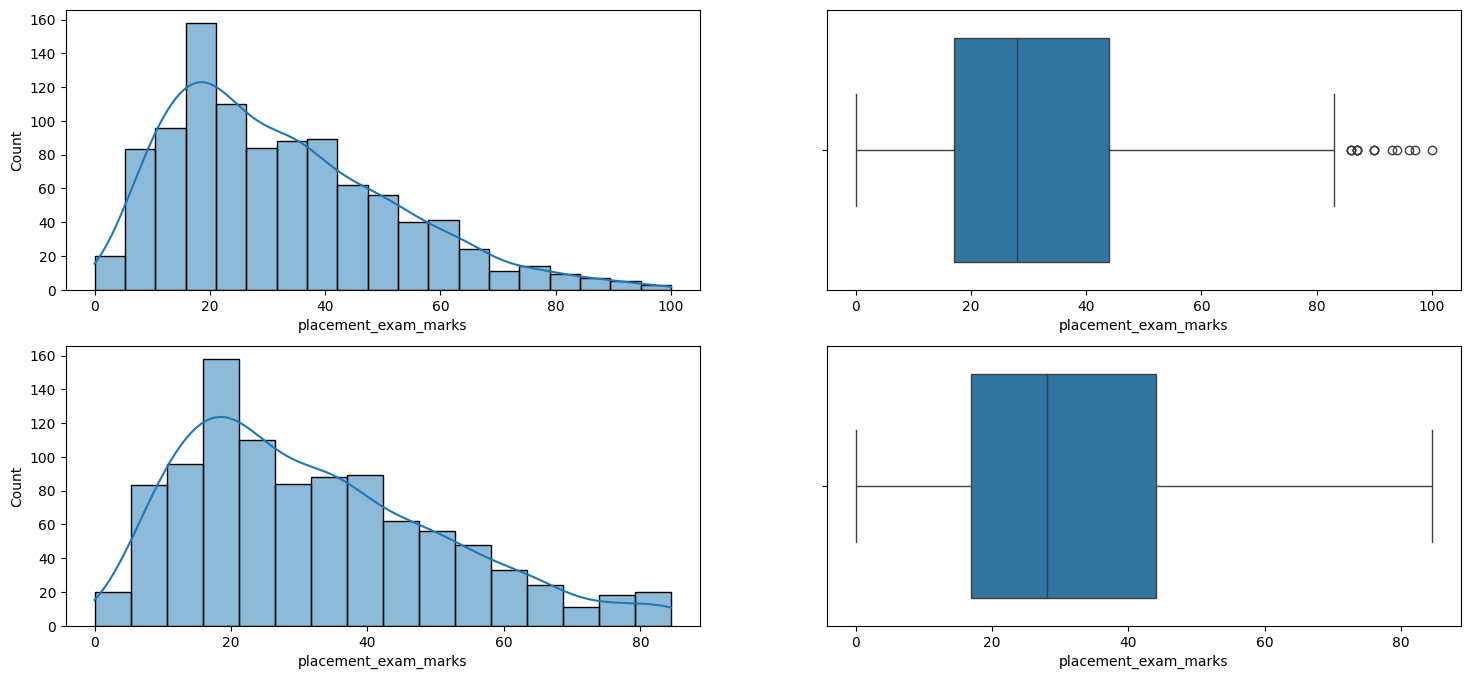

In [78]:
# Comparing Before After Removing Outlier

plt.figure(figsize=(18,8))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'] , kde=True)

plt.subplot(222)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(223)
sns.histplot(new_df['placement_exam_marks'] , kde=True)

plt.subplot(224)
sns.boxplot(x = new_df['placement_exam_marks'])

plt.show()
